# Phase 5 — Monitoring System & Automation

**Goal:** Simulate the automated monitoring pipeline across multiple runs and scenarios, then visualize the trends that Power BI will display.

## Steps
1. Run all 4 scenarios once
2. Simulate 10 runs of gradual drift
3. Plot F1 trend over time
4. Plot drift ratio over time
5. Alert log review

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
EXPORTS_DIR = Path('../data/monitoring_exports')

## 1. Run All Scenarios Once

In [2]:
from src.monitoring import run_monitoring_pipeline

scenarios = ['baseline', 'noise', 'speaker_split', 'gradual']
results = {}

for scenario in scenarios:
    print(f'\n--- Running scenario: {scenario} ---')
    alert = run_monitoring_pipeline(
        config_path='../configs/config.yaml',
        features_dir='../data/features',
        models_dir='../models',
        exports_dir='../data/monitoring_exports',
        scenario=scenario,
        batch_size=100,
    )
    results[scenario] = alert


--- Running scenario: baseline ---

Simulating incoming batch — scenario: 'baseline' | size: 100
  Inference done — Acc: 0.5600  F1: 0.5213

  MONITORING ALERT CHECK — 2026-06-06 20:22:58
  Scenario      : baseline
  KS Drift      : 5.0%  ✅ (threshold: 30%)
  F1 Score      : 0.5213  (baseline: 0.5986, drop: +0.0773)
  Perf Alert    : 🚨 YES — F1 dropped
  Overall       : 🚨 ALERT
  Report saved → monitoring_log.csv

--- Running scenario: noise ---

Simulating incoming batch — scenario: 'noise' | size: 100
  Inference done — Acc: 0.1000  F1: 0.0826

  MONITORING ALERT CHECK — 2026-06-06 20:22:58
  Scenario      : noise
  KS Drift      : 67.9%  🚨 (threshold: 30%)
  F1 Score      : 0.0826  (baseline: 0.5986, drop: +0.5160)
  Perf Alert    : 🚨 YES — F1 dropped
  Overall       : 🚨 ALERT
  Report saved → monitoring_log.csv

--- Running scenario: speaker_split ---

Simulating incoming batch — scenario: 'speaker_split' | size: 100
  Inference done — Acc: 0.8800  F1: 0.8796

  MONITORING ALERT C

## 2. Simulate 10 Runs of Gradual Drift
Mimics what happens when noise slowly increases over time (e.g. mic degrading)

In [3]:
import time

print('Simulating gradual drift over 10 runs...')
for i, noise_level in enumerate(np.linspace(0.0, 2.0, 10)):
    print(f'  Run {i+1}/10  noise_std={noise_level:.2f}')
    run_monitoring_pipeline(
        config_path='../configs/config.yaml',
        features_dir='../data/features',
        models_dir='../models',
        exports_dir='../data/monitoring_exports',
        scenario='noise',
        batch_size=80,
        noise_std=noise_level if noise_level > 0 else 0.01,
    )
    time.sleep(0.5)  # small pause so timestamps differ

print('Done.')

Simulating gradual drift over 10 runs...
  Run 1/10  noise_std=0.00

Simulating incoming batch — scenario: 'noise' | size: 80
  Inference done — Acc: 0.4375  F1: 0.3874

  MONITORING ALERT CHECK — 2026-06-06 20:22:58
  Scenario      : noise
  KS Drift      : 32.9%  🚨 (threshold: 30%)
  F1 Score      : 0.3874  (baseline: 0.5986, drop: +0.2112)
  Perf Alert    : 🚨 YES — F1 dropped
  Overall       : 🚨 ALERT
  Report saved → monitoring_log.csv
  Run 2/10  noise_std=0.22

Simulating incoming batch — scenario: 'noise' | size: 80
  Inference done — Acc: 0.1000  F1: 0.1019

  MONITORING ALERT CHECK — 2026-06-06 20:22:59
  Scenario      : noise
  KS Drift      : 52.5%  🚨 (threshold: 30%)
  F1 Score      : 0.1019  (baseline: 0.5986, drop: +0.4967)
  Perf Alert    : 🚨 YES — F1 dropped
  Overall       : 🚨 ALERT
  Report saved → monitoring_log.csv
  Run 3/10  noise_std=0.44

Simulating incoming batch — scenario: 'noise' | size: 80
  Inference done — Acc: 0.1000  F1: 0.0824

  MONITORING ALERT CHECK

## 3. Load Monitoring Log

In [4]:
monitor_df = pd.read_csv(EXPORTS_DIR / 'monitoring_log.csv')
monitor_df['timestamp'] = pd.to_datetime(monitor_df['timestamp'])
monitor_df = monitor_df.sort_values('timestamp').reset_index(drop=True)

print(f'Total monitoring runs: {len(monitor_df)}')
monitor_df.tail(10)

Total monitoring runs: 14


,timestamp,scenario,batch_size,batch_acc,batch_f1,baseline_f1,f1_drop,ks_drift_ratio,mean_ks_stat,mean_wasserstein,drift_alert,perf_alert,status
4,2026-06-06 20:22:58,noise,80,0.4375,0.3874,0.5986,0.2112,0.3292,0.1445,0.2482,True,True,🚨 ALERT
5,2026-06-06 20:22:59,noise,80,0.1000,0.1019,0.5986,0.4967,0.5250,0.2506,0.2812,True,True,🚨 ALERT
6,2026-06-06 20:23:00,noise,80,0.1000,0.0824,0.5986,0.5162,0.6292,0.2856,0.4265,True,True,🚨 ALERT
7,2026-06-06 20:23:01,noise,80,0.1000,0.0824,0.5986,0.5162,0.6625,0.3082,0.5407,True,True,🚨 ALERT
8,2026-06-06 20:23:01,noise,80,0.1375,0.1128,0.5986,0.4858,0.6792,0.3248,0.6509,True,True,🚨 ALERT
9,2026-06-06 20:23:02,noise,80,0.1000,0.0946,0.5986,0.5040,0.6875,0.3371,0.7750,True,True,🚨 ALERT
10,2026-06-06 20:23:03,noise,80,0.1000,0.0946,0.5986,0.5040,0.7042,0.3465,0.9090,True,True,🚨 ALERT
11,2026-06-06 20:23:03,noise,80,0.1125,0.0930,0.5986,0.5056,0.7292,0.3545,1.0427,True,True,🚨 ALERT
12,2026-06-06 20:23:04,noise,80,0.1250,0.1000,0.5986,0.4986,0.7583,0.3634,1.1926,True,True,🚨 ALERT
13,2026-06-06 20:23:05,noise,80,0.0875,0.0911,0.5986,0.5075,0.7750,0.3684,1.3843,True,True,🚨 ALERT


## 4. F1 Trend Over Time

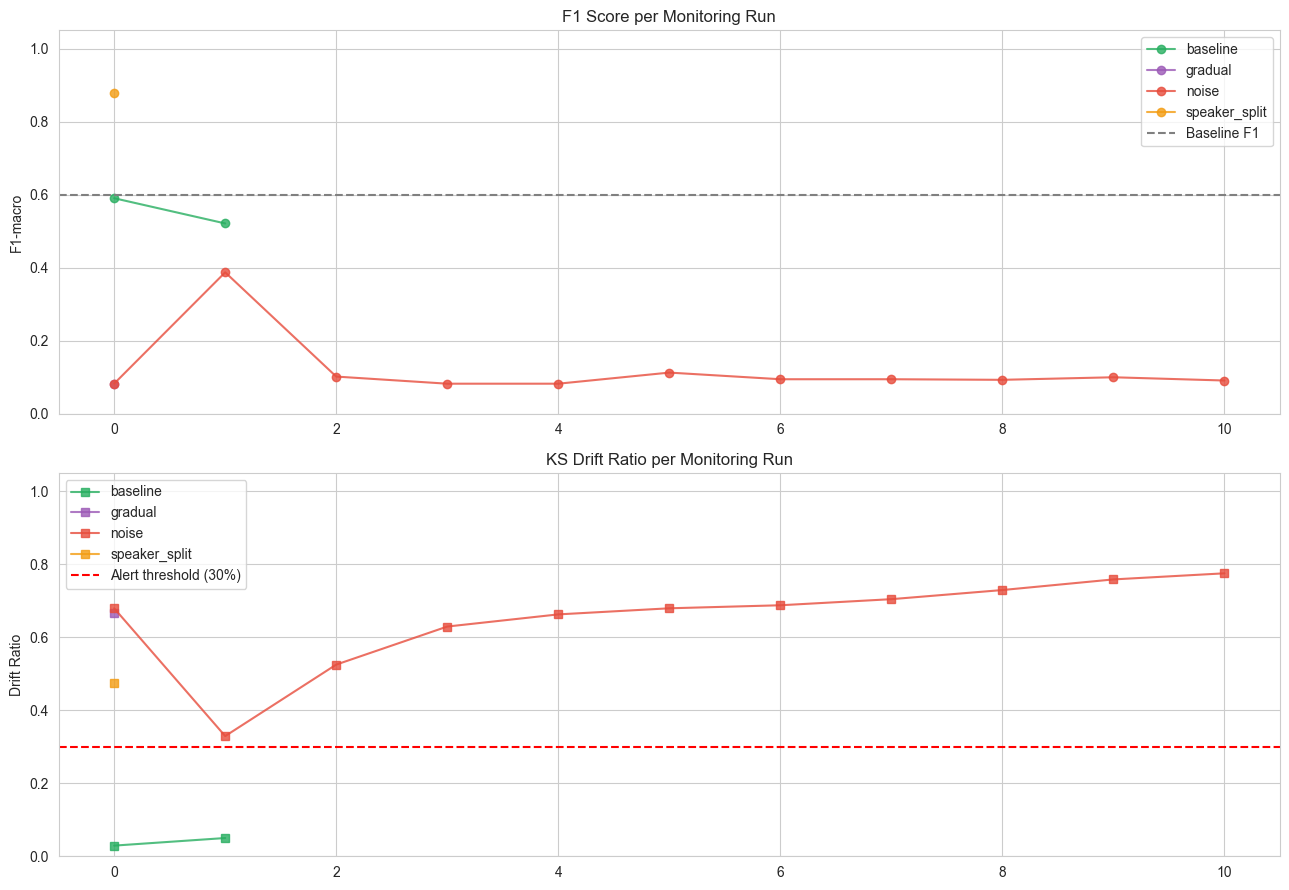

In [5]:
alert_df = pd.read_csv(EXPORTS_DIR / 'alert_log.csv')
alert_df['timestamp'] = pd.to_datetime(alert_df['timestamp'])
alert_df = alert_df.sort_values('timestamp').reset_index(drop=True)

SCENARIO_COLORS = {
    'baseline':     '#27ae60',
    'noise':        '#e74c3c',
    'speaker_split':'#f39c12',
    'gradual':      '#9b59b6',
}

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=False)

# F1 over time
ax = axes[0]
for scenario, grp in alert_df.groupby('scenario'):
    ax.plot(range(len(grp)), grp['f1_score'], marker='o',
            label=scenario, color=SCENARIO_COLORS.get(scenario, '#3498db'), alpha=0.8)
ax.axhline(alert_df['baseline_f1'].iloc[0], color='gray',
           linestyle='--', linewidth=1.5, label='Baseline F1')
ax.set_title('F1 Score per Monitoring Run', fontsize=12)
ax.set_ylabel('F1-macro')
ax.set_ylim(0, 1.05)
ax.legend()

# Drift ratio over time
ax2 = axes[1]
for scenario, grp in alert_df.groupby('scenario'):
    ax2.plot(range(len(grp)), grp['ks_drift_ratio'], marker='s',
             label=scenario, color=SCENARIO_COLORS.get(scenario, '#3498db'), alpha=0.8)
ax2.axhline(0.3, color='red', linestyle='--', linewidth=1.5, label='Alert threshold (30%)')
ax2.set_title('KS Drift Ratio per Monitoring Run', fontsize=12)
ax2.set_ylabel('Drift Ratio')
ax2.set_ylim(0, 1.05)
ax2.legend()

plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'monitoring_trends.png', dpi=120)
plt.show()

## 5. Alert Log Summary

In [6]:
print('\nALERT LOG SUMMARY')
print('=' * 60)
summary = alert_df.groupby('scenario').agg(
    runs=('timestamp', 'count'),
    alerts=('any_alert', 'sum'),
    avg_f1=('f1_score', 'mean'),
    avg_drift=('ks_drift_ratio', 'mean'),
).round(4)
summary['alert_rate'] = (summary['alerts'] / summary['runs']).round(2)
print(summary.to_string())

# Save summary for Power BI
summary.to_csv(EXPORTS_DIR / 'monitoring_summary.csv')
print(f'\nSaved monitoring_summary.csv')


ALERT LOG SUMMARY
               runs  alerts  avg_f1  avg_drift  alert_rate
scenario                                                  
baseline          2       1  0.5558     0.0396         0.5
gradual           1       1  0.0826     0.6667         1.0
noise            11      11  0.1203     0.6508         1.0
speaker_split     1       1  0.8796     0.4750         1.0

Saved monitoring_summary.csv


## 6. How to Use with n8n / Kestra

### n8n
```
1. Start n8n:  npx n8n
2. Open http://localhost:5678
3. Import pipeline/n8n_workflow.json
4. Update the project path in the Execute Command node
5. Add email credentials → Activate
```

### Kestra
```
1. Start Kestra:  docker-compose up (see kestra.io/docs)
2. Upload pipeline/kestra_flow.yaml via UI or API
3. Set ALERT_EMAIL secret in Kestra Settings
4. Trigger manually or wait for hourly cron
```

### Python Scheduler (lightweight alternative)
```bash
# Run every 60 seconds (for demo)
python src/monitoring.py --schedule 60 --scenario baseline

# Simulate noise drift every 30 seconds
python src/monitoring.py --schedule 30 --scenario noise --noise_std 1.5
```